In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\wahiduzzaman.fahad\Downloads\ai_job_trends_dataset (1).csv")

df 

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"Psychotherapist, dance movement",Education,Increasing,Moderate,142238.00,PhD,16,7816,1363,56.91,27.27,China,65.90
29996,"Scientist, water quality",IT,Decreasing,Moderate,123107.50,Associate Degree,19,9358,7632,27.25,12.84,UK,31.18
29997,Web designer,Manufacturing,Decreasing,Moderate,97305.51,Master’s Degree,0,9605,2559,31.76,16.82,China,26.07
29998,Primary school teacher,Entertainment,Increasing,Moderate,95599.22,High School,15,5481,4879,32.46,45.93,Brazil,40.43


In [3]:
df.groupby('Job Status').mean(numeric_only=True)

,Median Salary (USD),Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Gender Diversity (%)
Job Status,,,,,,,
Decreasing,90087.161471,9.994080,5052.061222,5056.948466,49.765404,50.089395,50.009038
Increasing,90152.180303,10.107756,5027.443644,5091.177392,49.906182,50.217899,49.950811


In [4]:
df['Location'].unique()

array(['UK', 'USA', 'Canada', 'Australia', 'Germany', 'China', 'India',
       'Brazil'], dtype=object)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Industry', ylabel='count'>

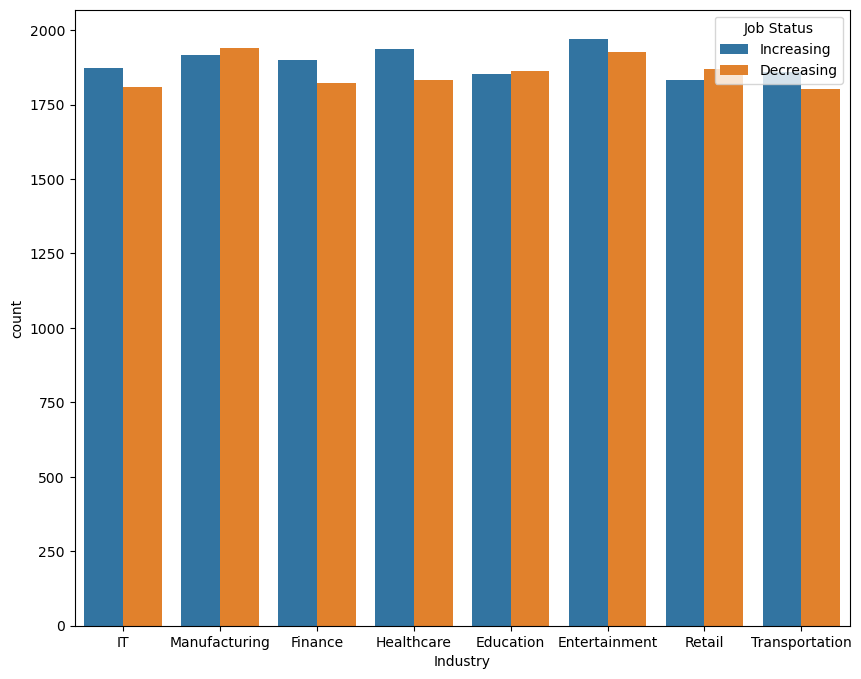

In [6]:
plt.figure(figsize=(10,8))
sns.countplot(x='Industry', hue='Job Status', data=df)

<Axes: xlabel='AI Impact Level', ylabel='count'>

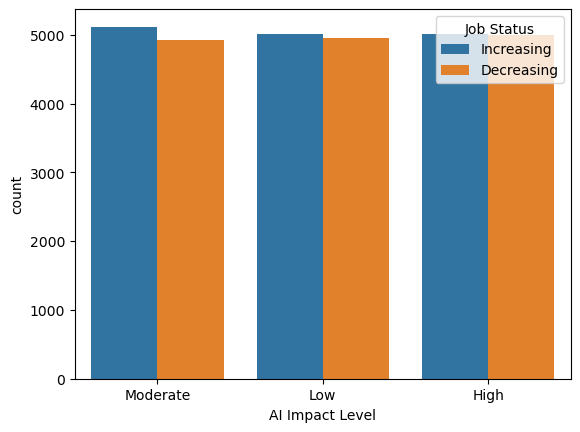

In [7]:
sns.countplot(x='AI Impact Level', hue='Job Status', data=df)

<Axes: xlabel='Required Education', ylabel='count'>

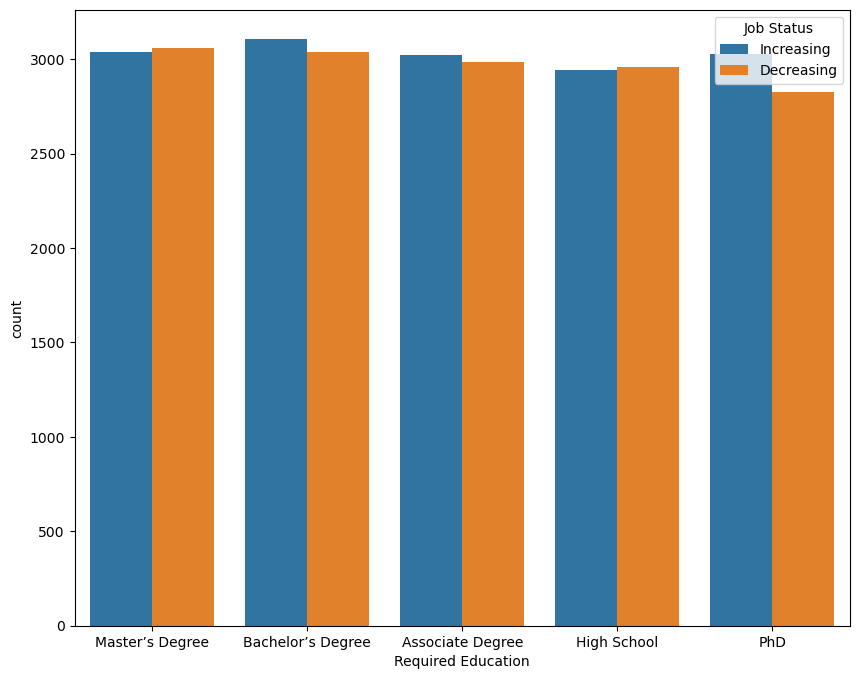

In [8]:
plt.figure(figsize=(10,8))
sns.countplot(x='Required Education', hue='Job Status', data=df)

<Axes: xlabel='Location', ylabel='count'>

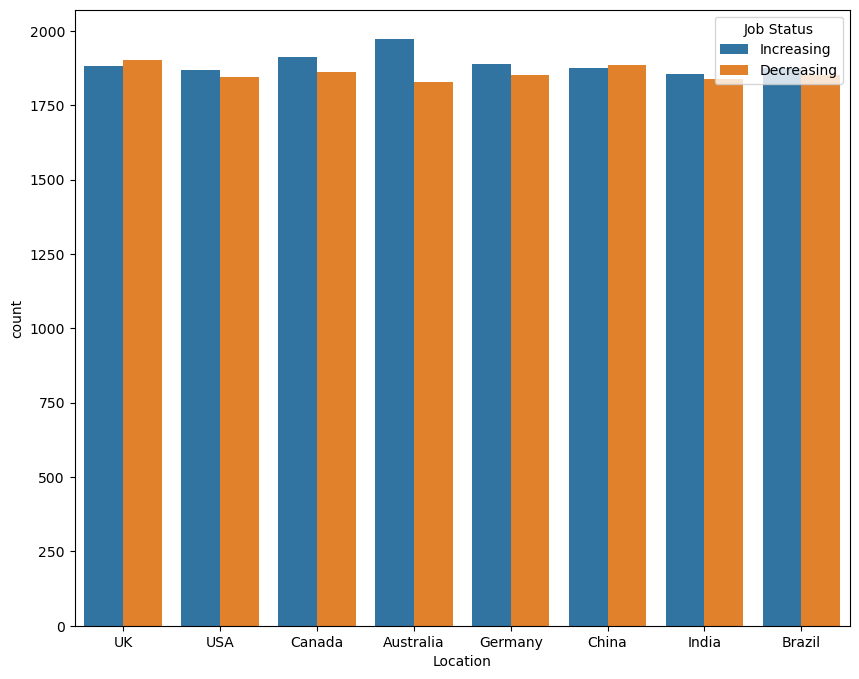

In [9]:
plt.figure(figsize=(10,8))
sns.countplot(x='Location', hue='Job Status', data=df)

In [10]:
df

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"Psychotherapist, dance movement",Education,Increasing,Moderate,142238.00,PhD,16,7816,1363,56.91,27.27,China,65.90
29996,"Scientist, water quality",IT,Decreasing,Moderate,123107.50,Associate Degree,19,9358,7632,27.25,12.84,UK,31.18
29997,Web designer,Manufacturing,Decreasing,Moderate,97305.51,Master’s Degree,0,9605,2559,31.76,16.82,China,26.07
29998,Primary school teacher,Entertainment,Increasing,Moderate,95599.22,High School,15,5481,4879,32.46,45.93,Brazil,40.43


In [11]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Location_n'] = encoder.fit_transform(df['Location'])
df['industry_n'] = encoder.fit_transform(df['Industry'])
df['Job Status_n'] = encoder.fit_transform(df['Job Status'])


In [16]:
df['industry_n'].unique()

array([4, 5, 2, 3, 0, 1, 6, 7])

In [13]:
X = df[['Experience Required (Years)', 'Location_n', 'industry_n']]

y = df['Job Status_n']

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X, y)

model.score(X, y)

0.5068333333333334

In [17]:
model.predict([[12, 4, 6]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [18]:
df

,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%),Location_n,industry_n,Job Status_n
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63,6,4,1
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39,7,5,1
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13,2,2,1
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76,0,3,1
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57,4,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,"Psychotherapist, dance movement",Education,Increasing,Moderate,142238.00,PhD,16,7816,1363,56.91,27.27,China,65.90,3,0,1
29996,"Scientist, water quality",IT,Decreasing,Moderate,123107.50,Associate Degree,19,9358,7632,27.25,12.84,UK,31.18,6,4,0
29997,Web designer,Manufacturing,Decreasing,Moderate,97305.51,Master’s Degree,0,9605,2559,31.76,16.82,China,26.07,3,5,0
29998,Primary school teacher,Entertainment,Increasing,Moderate,95599.22,High School,15,5481,4879,32.46,45.93,Brazil,40.43,1,1,1
